## E1: Load and Inspect

1. Load the CSV.

In [2]:
import pandas as pd
data = pd.read_csv('/Users/laven/Documents/TKH/-citibike-ridership-model-/Data/citibike_weather_daily.csv')

2. Inspect the CSV's Structure

a. Shape

In [3]:
data.shape

(1610, 12)

b. Data Types

In [4]:
data.dtypes

ride_date               str
num_rides             int64
avg_duration_min    float64
day                   int64
day_of_week             str
month                 int64
obs_date                str
temp_f              float64
max_temp_f          float64
min_temp_f          float64
wind_speed_knots    float64
precip_in           float64
dtype: object

c. Head

In [5]:
data.head()

,ride_date,num_rides,avg_duration_min,day,day_of_week,month,obs_date,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in
0,2015-03-26,14954,11.843317,26,Thursday,3,2015-03-26,45.2,57.0,32.0,4.4,0.05
1,2015-02-02,1459,15.347704,2,Monday,2,2015-02-02,29.6,36.0,19.9,11.2,0.84
2,2015-11-05,43006,15.287938,5,Thursday,11,2015-11-05,62.0,71.1,55.0,3.3,0.00
3,2015-02-21,3157,9.848833,21,Saturday,2,2015-02-21,20.1,28.9,3.0,8.0,0.01
4,2015-02-08,6662,11.115628,8,Sunday,2,2015-02-08,33.0,36.0,26.1,8.9,0.01


The ride date column loaded as a string. The ride date's data type is date in the data dictionary. Date types are often parsed as strings by default to prevent the data from being corrupted.

## E2: Profile the Distribution

1. Run describe() on the numeric columns

In [6]:
data.describe()

,num_rides,avg_duration_min,day,month,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,32986.783230,15.425627,15.714907,6.544099,57.368509,67.317081,49.295901,9.013913,0.178398
std,16910.147968,3.652633,8.806113,3.323772,17.876211,18.349408,17.832318,3.241211,2.508762
min,876.000000,9.495396,1.000000,1.000000,8.300000,18.000000,1.000000,2.300000,0.000000
25%,20505.500000,13.112342,8.000000,4.000000,43.625000,53.700000,35.700000,6.700000,0.000000
50%,32272.500000,14.860057,16.000000,7.000000,59.300000,70.000000,51.100000,8.500000,0.000000
75%,42915.750000,17.121551,23.000000,9.000000,73.500000,82.900000,64.900000,10.800000,0.060000
max,78458.000000,81.110084,31.000000,12.000000,92.500000,100.900000,82.900000,22.400000,99.990000


2.Histograms

Import pyplot from matplotlib and seaborn

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

a. Number of Rides

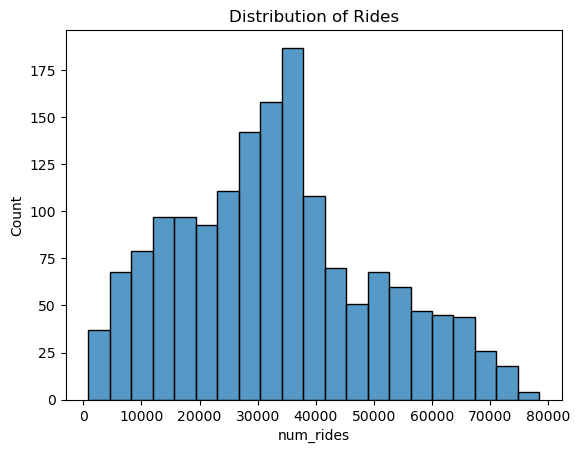

In [8]:
fig = sns.histplot(data['num_rides'])
fig.set_title('Distribution of Rides');

b. Average Duration in Minutes

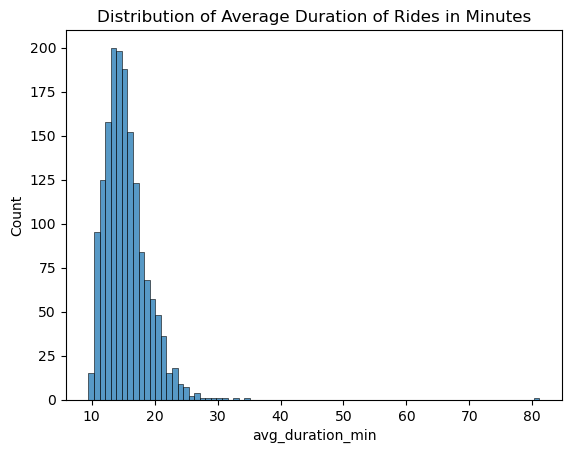

In [9]:
fig = sns.histplot(data['avg_duration_min'])
fig.set_title('Distribution of Average Duration of Rides in Minutes');

c. Temperature

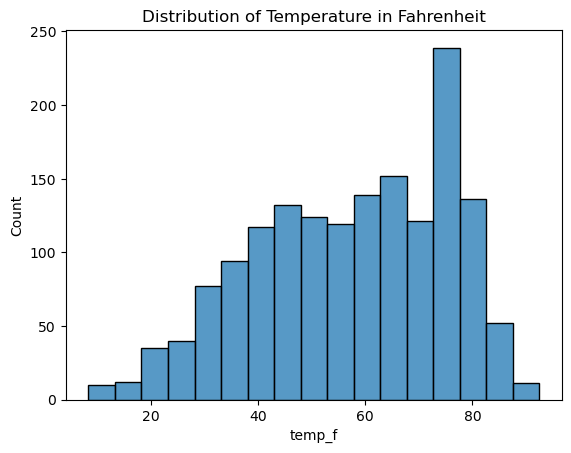

In [10]:
fig = sns.histplot(data['temp_f'])
fig.set_title('Distribution of Temperature in Fahrenheit');

d. Maximum Temperature

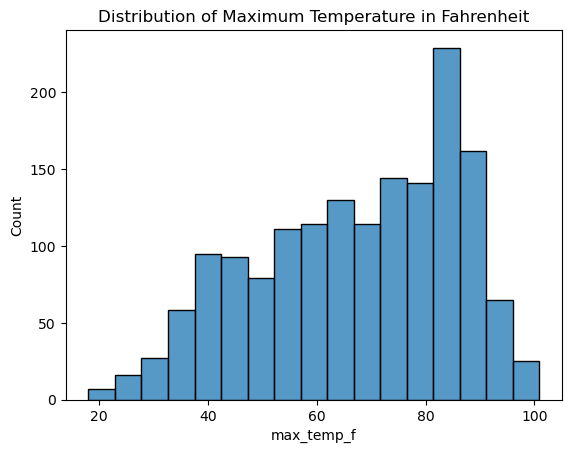

In [11]:
fig = sns.histplot(data['max_temp_f'])
fig.set_title('Distribution of Maximum Temperature in Fahrenheit');

d.Minimum Tepmperature

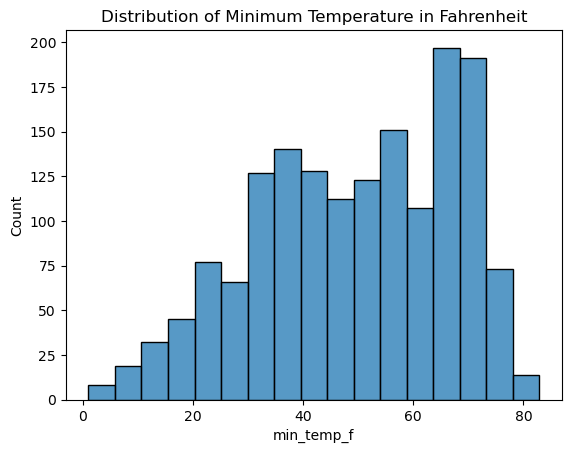

In [12]:
fig = sns.histplot(data['min_temp_f'])
fig.set_title('Distribution of Minimum Temperature in Fahrenheit');

e. Wind Speed

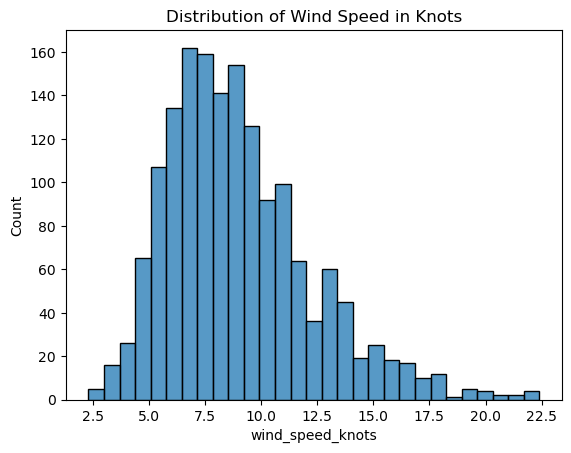

In [13]:
fig = sns.histplot(data['wind_speed_knots'])
fig.set_title('Distribution of Wind Speed in Knots');

f. Precipitation

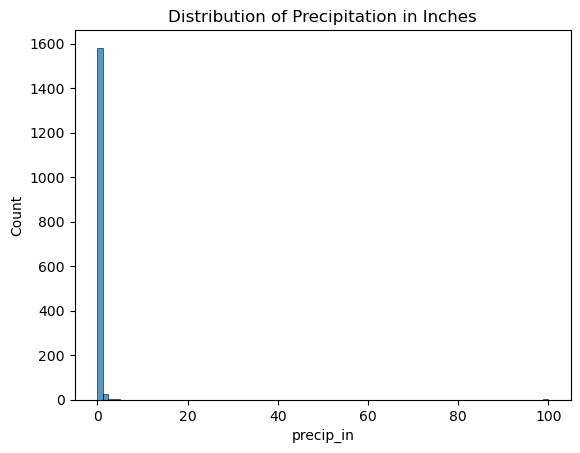

In [14]:
fig = sns.histplot(data['precip_in'])
fig.set_title('Distribution of Precipitation in Inches');

In [15]:
missing_temp =( data['temp_f'] == 9999.9)
print(missing_temp.sum()) 

missing_wind =( data['wind_speed_knots'] == 999.9)
print(missing_wind.sum()) 

missing_precip =( data['precip_in'] == 99.99) 
print(missing_precip.sum()) 

rows_with_missing_precip = data[missing_precip]
print(rows_with_missing_precip)


0
0
1
      ride_date  num_rides  avg_duration_min  day day_of_week  month  \
227  2016-02-11      18748         13.523118   11    Thursday      2   

       obs_date  temp_f  max_temp_f  min_temp_f  wind_speed_knots  precip_in  
227  2016-02-11    28.1        39.9        23.0              17.3      99.99  


 One missing value added as a number did make it into this slice of data. Precipitation has one value.

## E3: Relationships with the Target

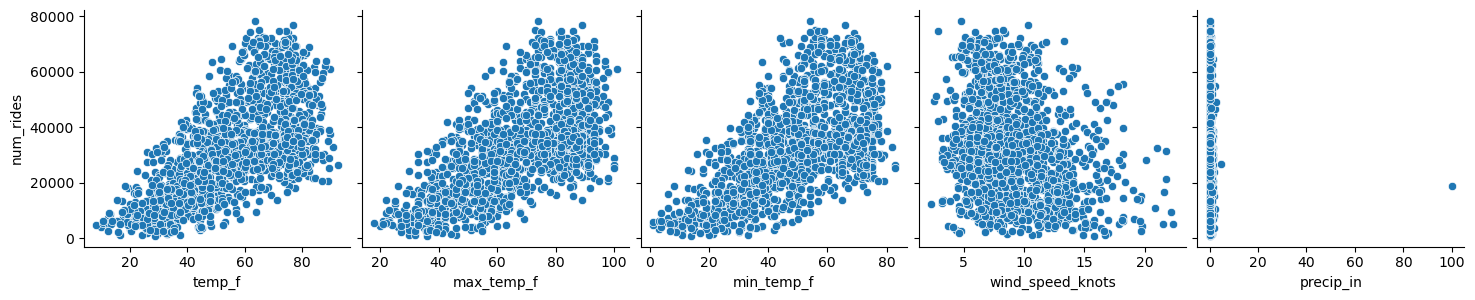

In [16]:
weather_variables = ['temp_f','max_temp_f', 'min_temp_f','wind_speed_knots','precip_in']

sns.pairplot(data=data, x_vars=weather_variables, y_vars=['num_rides'], height=3)
plt.show()

The temperature, maximum temperature, minimum temperature, and wind speed have a strong relationshhip to the number of rides.The precipitation variable has a weak relationship to the number of rides.The temperature relationship is linear. Ridership increases throughout the day as temperature rises, but ridership doesn't climb forever. Fewer dots are notieced  beyond the 80 degree mark on the number of rides-temperature scatterplot.



## E4: Ridership Over Time

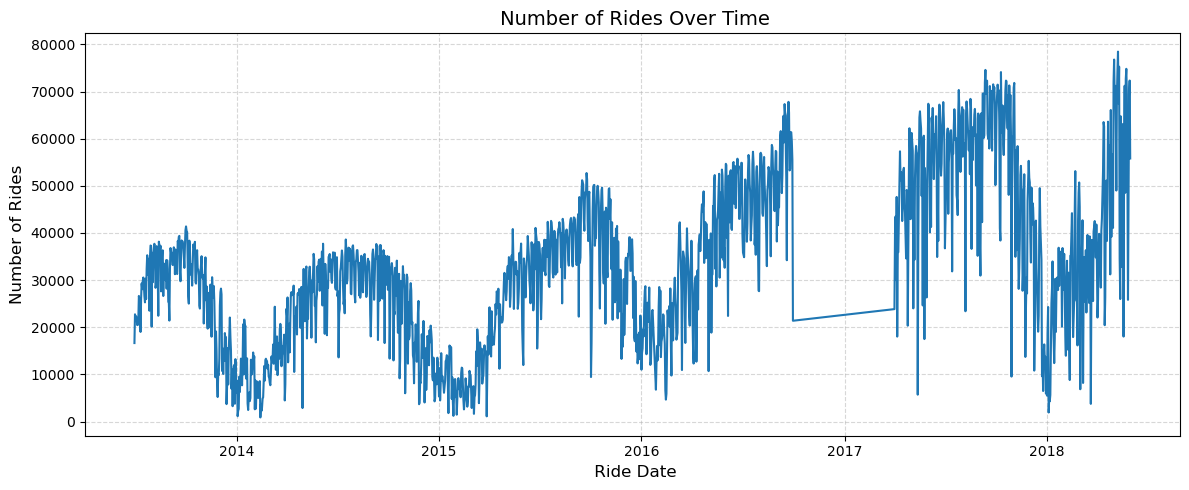

In [17]:
data['ride_date'] = pd.to_datetime(data['ride_date'])
data = data.sort_values('ride_date')

# Plot num_rides over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=data, x='ride_date', y='num_rides', linewidth=1.5)

plt.title(' Number of Rides Over Time', fontsize=14, pad=6)
plt.xlabel(' Ride Date', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

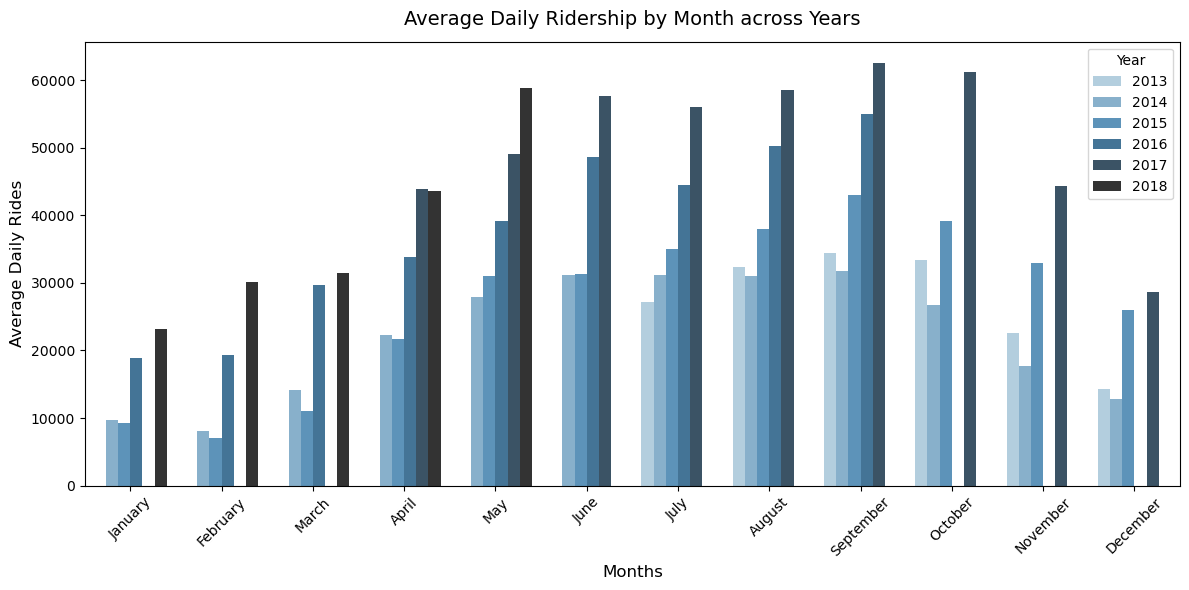

In [18]:

data['year'] = data['ride_date'].dt.year
data['month'] = data['ride_date'].dt.month_name()
month_order = ['January','February','March','April','May','June','July','August',
               'September','October','November','December']
data['month'] = pd.Categorical(data['month'], categories=month_order, ordered=True)
plt.figure(figsize=(12, 6))
sns.barplot(data=data, x= data['month'], y='num_rides',hue='year',estimator='mean',errorbar=None,
            palette= 'Blues_d',)
plt.title('Average Daily Ridership by Month across Years', fontsize=14, pad=12)
plt.xlabel('Months', fontsize=12)
plt.ylabel('Average Daily Rides', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

/var/folders/m2/z5wk54_n69g89dfbp9dpv6xh0000gp/T/ipykernel_37839/1795311328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


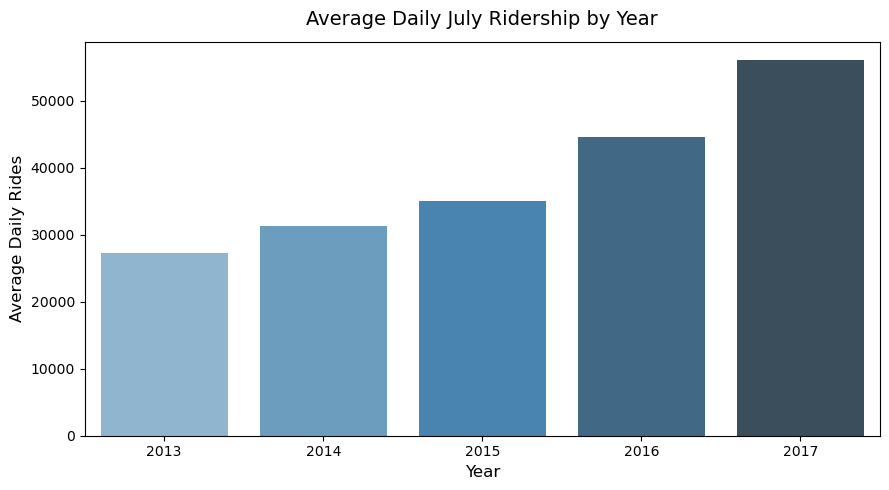

In [19]:
july_data = data[data['ride_date'].dt.month == 7]
plt.figure(figsize=(9, 5))
sns.barplot(
    data=july_data,
    x='year',
    y='num_rides',
    estimator='mean',
    errorbar=None,
    palette='Blues_d',
)

plt.title('Average Daily July Ridership by Year', fontsize=14, pad=12)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Daily Rides', fontsize=12)
plt.tight_layout()
plt.show()


A July in 2013 is 4 years before a July in 2017, completely different even at identical weather. A model whose inputs are only weather or days of the week can possibly predict the weather on a given day of the week.

## E5: The Weekly Rhythm
a. Bar Chart
 



/var/folders/m2/z5wk54_n69g89dfbp9dpv6xh0000gp/T/ipykernel_37839/3407184909.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


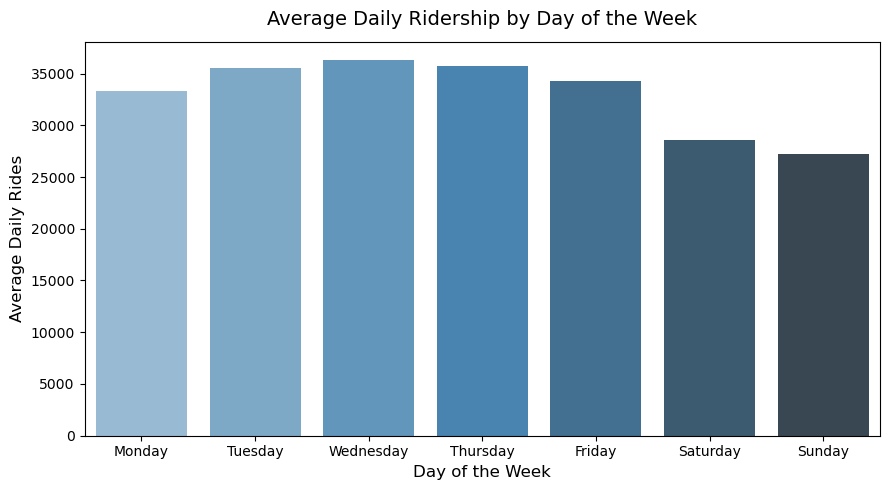

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=data,
    x=data['day_of_week'],
    y=data['num_rides'],
    estimator='mean',
    errorbar=None,
    palette='Blues_d',
)
plt.title('Average Daily Ridership by Day of the Week', fontsize=14, pad=12)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Daily Rides', fontsize=12)
plt.tight_layout()
plt.show()

b. Boxplot

/var/folders/m2/z5wk54_n69g89dfbp9dpv6xh0000gp/T/ipykernel_37839/1516838426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


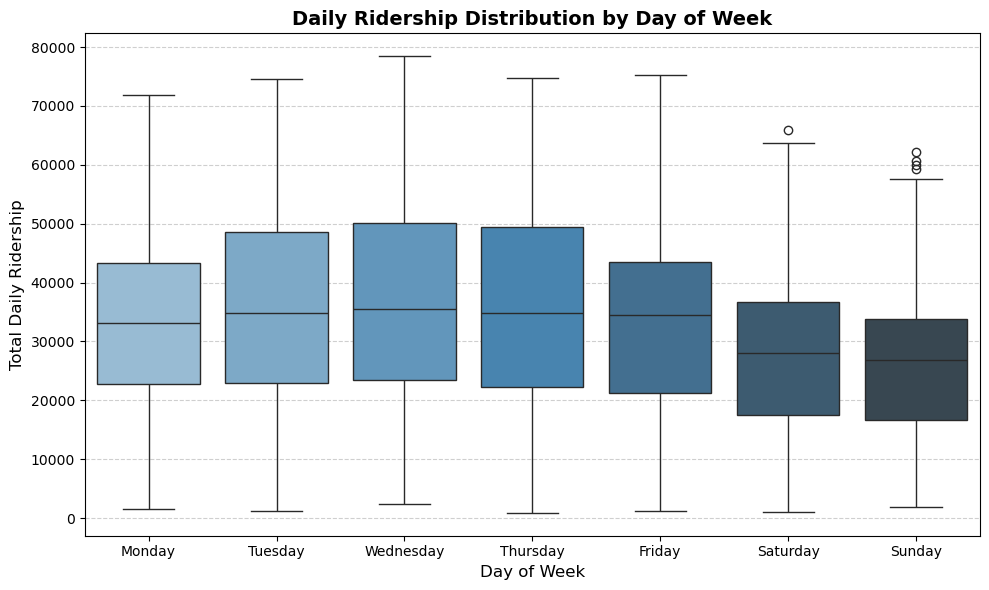

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=data,
    x=data['day_of_week'],
    y=data['num_rides'],
    palette='Blues_d'
)

plt.title('Daily Ridership Distribution by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Daily Ridership', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Tuesdays, Wednesdays, and Thursdays are the busiest. Anyone working Monday through Friday rides citibike. These people don't woek over the weekend.
